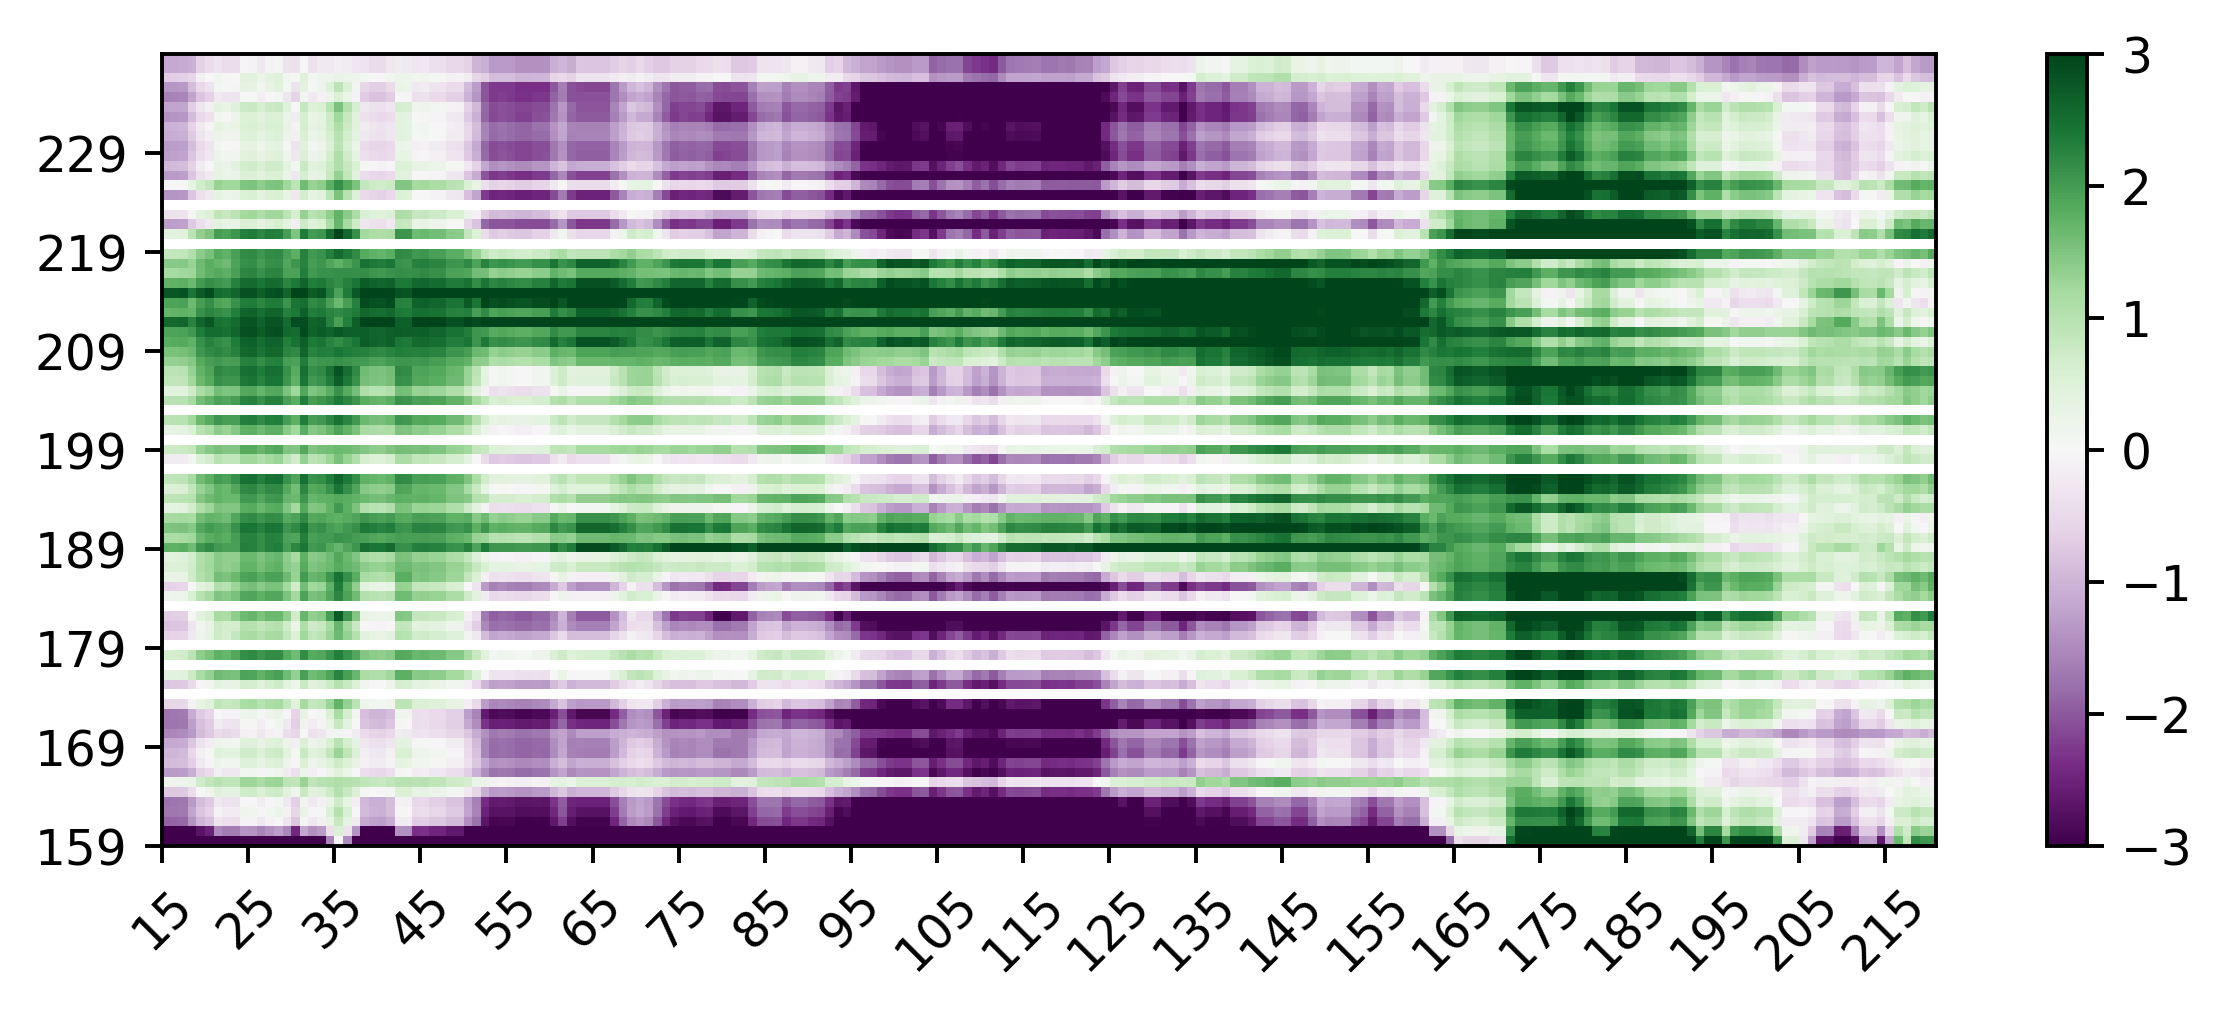

In [2]:
# note we needed the folded_domain_utils module because this lets us build a FoldedDomain, which is
# where all the magic happens...
from finches.utils import folded_domain_utils
from finches import Mpipi_frontend

# import for plotting
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

# initialize a CALVADOS frontend object
mf = Mpipi_frontend()

# define the sequence of your IDR of interest
gcn4_ntd         = 'MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNT'

# initialize a FoldedDomain using a PDB file. This initialize will under the hood do a bunch
# of things needed to map surface:IDR intermaps
FD = folded_domain_utils.FoldedDomain('ADBD1.pdb')


# set window size, we recommend 31 for consistencty with IDR:IDR intermaps but this value may need
# to be smaller if you have a smaller IDR or folded domain.
window_size = 31

# we have this here just to ensure the window size is odd...
if window_size % 2 != 1:
    raise Exception('window_size must be odd')

# calculate surface:IDR intermap. This is where the magic happens...
X = FD.calculate_idr_surface_patch_interactions(gcn4_ntd, mf.IMC_object, window_size)

### PLOT FD:IDR intermap

# define settings for visualization
vmax=3
vmin=-3
cmap='PRGn'
tic_frequency = 10

# we have to calculate where the IDR sequence is going to start/end based on splitting the window into N/C terminal halbves
half_window = int((window_size-1)/2)
idr_start = half_window
idr_end = len(gcn4_ntd) - half_window

# we define the start and end induces for he folded domain
fd_start = 1
fd_end = len(FD)

# this is the residue where the fd starts in its original protein
fd_offset = 158

figure(None, (7,3), dpi=350)

# X[1] here is a (81, 206) matrix with surface:IDR interactions (FD =81 residues, IDR=236, and we loose 30 residues from the sliding window)
plt.imshow(X[1], extent=[idr_start, idr_end, fd_start, fd_end], origin='lower', aspect='auto', vmax=vmax, vmin=vmin, cmap=cmap)
ax = plt.gca()

# Set the axis tick values to be interpretable numbers
ax.set_yticks(np.arange(fd_start, fd_end, tic_frequency), np.arange(fd_start+fd_offset, fd_end+fd_offset, tic_frequency))
ax.set_xticks(np.arange(idr_start, idr_end, tic_frequency))
ax.tick_params(axis='x', rotation=45)  # Rotates the x-tick labels by 45 degrees

plt.colorbar()
plt.tight_layout()